# Test sequence for Confocal Alignment
### Alignment off silver mirror at room temperature

In [1]:
import time
import pandas as pd
import pyvisa
import matplotlib.pyplot as plt
import numpy as np
import time
import logging
import sys
import os

In [2]:
# directory structure
current_file = '20250915 confocal alignment.ipynb'
current_dir = os.path.dirname(os.path.abspath(current_file)) # Angela Experiments
print(current_dir)
parent_dir = os.path.dirname(current_dir) # Longterm_sweeps
print(parent_dir)

# append parent directory (longterm_sweeps) to sys.path -> search for files in this branch
sys.path.append(parent_dir)

c:\Users\Waluigi\Documents\GitHub\longterm_sweeps\Angela Experiments
c:\Users\Waluigi\Documents\GitHub\longterm_sweeps


In [3]:
# check USB connections
rm = pyvisa.ResourceManager()
rm.list_resources()

ValueError: Could not locate a VISA implementation. Install either the IVI binary or pyvisa-py.

## ANC300 initialisation

In [4]:
from drivers.attocube_anc300 import ANC300

anc_address = 'ASRL11::INSTR' # change as needed
anc = ANC300(name = 'anc300', address = anc_address)
a1 = anc.submodules['axis1'] # confocal attocube controlled through axis 1

### ANC300 parameters - frequency, voltage, amplitude, mode

In [5]:
# anc.a1.amplitude() # set maximum level of output signal in [0, 150]V
print( "AMPLITUDE ", a1.amplitude(), 'V') # read maximum amplitude. set at 32V manually, for calibration.

AMPLITUDE  32.0 V


In [6]:
anc.axis1.frequency(400) # arbitrarily set movement frequency at 400Hz
print( "FREQUENCY ", a1.frequency(), 'Hz') # verify frequency change on front module of ANC300

FREQUENCY  400 Hz


c:\Users\Waluigi\Documents\GitHub\longterm_sweeps\drivers\attocube_anc300.py:448: UserWarning: read string doesn't end with termination characters
  response = self.visa_handle.read() # read the response line again


In [7]:
a1.mode('stp') # choose step mode

## Rigol Oscilloscope Initialisation

In [8]:
from qil_Rigol.rigol import cRigol

osc = cRigol('10.196.50.21') # IP address of Rigol MSO5104 is: 10.196.50.21. verify connection here.

Connected to RIGOL TECHNOLOGIES,MSO5104,MS5A234906950,00.01.03.00.03
 succesfully 


In [9]:
# test readout and set the averages
osc.send(":ACQ:AVER 8")

# read the averages
print("Averages", osc.recieve(":ACQ:AVERages?"))

# most of Acquire actually has a function
osc.setAcquire(Averages = 8)

Averages 2

Averages set to :  2



In [10]:
# Rigol parameters - sweeptime, trigger, offset, scale
sweepTime = 1
osc.setTimebase(hrefMode="TRIG", mainOffset = sweepTime/2, mainScale = sweepTime/(1))
osc.edgeTrigger(sweep="NORM", source = 4, edge = "POS", level = 200) # how does 'level' scale?

Main offset set to :  5.000000E-1

Main scale set to :  1.000000E0

Href mode set to :  TRIG

{'mode': 'EDGE', 'sweep': 'NORM'}


## UNI-T-61E Multimeter Initialisation

In [11]:
from drivers.uni_t_ut61e.ut61eplus.ut61eplus import UT61EPLUS
# driver requires pywinusb module - incompatible with macOS

In [12]:
dmm = UT61EPLUS()

In [13]:
def measure_resistance(dmm=dmm):
    meas = dmm.takeMeasurement()
    if not meas.overload:
        resistance  = meas.display
    else:
        resistance = -1
        print(f'WARNING: Overloaded Resistance. Check your sh*t')
    return resistance

In [14]:
measure_resistance()

'17.168'

In [15]:
# time taken for 1 measurement
start = time.time()
meas = dmm.takeMeasurement()
stop = time.time()

print (stop-start)

0.057505130767822266


## Alignment Sequence
Maintain and monitor step parameters - amplitude, frequency, and voltage!

In [16]:
anc.axis1.frequency(400) # arbitrarily set movement frequency at 400Hz

In [17]:
# read step parameters
print( "AMPLITUDE ", a1.amplitude(), 'V')
print( "FREQUENCY ", a1.frequency(), 'Hz') 
print( "VOLTAGE ", a1.voltage(), 'V')

AMPLITUDE  32.0 V
FREQUENCY  400 Hz
VOLTAGE  0.0 V


In [ ]:
# reset to forwards position
a1.move(13000)

Step attocube from front to back, starting with coarse full-range. Start measurement on Rigol with steps on attocube.

In [11]:
# modestly move to forward position
a1.move(8400)

### Move backwards and Store Data

In [77]:
a1.stopMove()

Start resistance: 14.777
Waiting for Trigger
Trigger Received


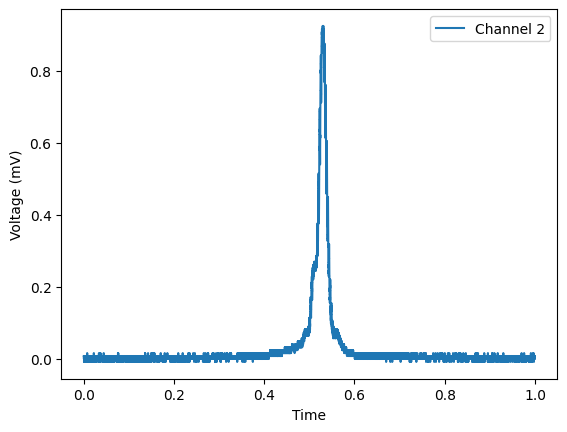

End resistance: 11.199


In [76]:
# read resistance as proxy for position
print('Start resistance:', measure_resistance())

# move backwards
a1.move(-12000)

# test plotting scope memory with external trigger
# more points than live read, but has to stop scope - not a problem for obtaining single-run response function
data = osc.readMemTriggered([2], timeout = 50, pts = '100k') # select channel 2 for plotting
plt.plot(data['time'], data['ch2'], label = 'Channel 2')
plt.xlabel('Time')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

# read resistance as proxy for position
print('End resistance:', measure_resistance())

data.to_csv('back_F_50_G3.csv', index=False) # index=False prevents writing the DataFrame index as a column

### Move Forwards and Store Data

In [79]:
a1.stopMove()

Start resistance: 10.397
Waiting for Trigger
Trigger Received


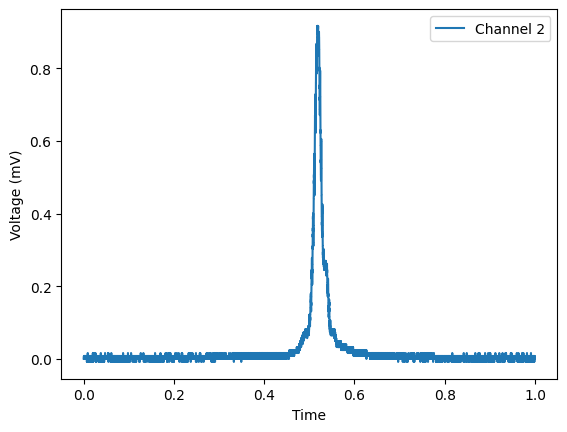

End resistance: 13.847


In [78]:
# read resistance as proxy for position
print('Start resistance:', measure_resistance())

# move forwards
a1.move(8000)

# test plotting scope memory with external trigger
# more points than live read, but has to stop scope - not a problem for obtaining single-run response function
data = osc.readMemTriggered([2], timeout = 50, pts = '100k') # select channel 2 for plotting
plt.plot(data['time'], data['ch2'], label = 'Channel 2')
plt.xlabel('Time')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

# read resistance as proxy for position
print('End resistance:', measure_resistance())

# save data
data.to_csv('forward_F_50_G4.csv', index=False) # index=False prevents writing the DataFrame index as a column

In [80]:
anc.close()
dmm.close()